# 17 · From messy laboratory data to a thermodynamic model

**Problem.** A student laboratory measured the vapour-liquid equilibrium of methanol and water at
atmospheric pressure and exported the results. The file has the faults such files always have. The task:
turn it into a clean data set, test it, fit an activity-coefficient model with uncertainties, and compare
with a prediction - the complete workflow of a thermodynamic property measurement.

**What you will learn**
- repair a real laboratory export (units, duplicates, typos, missing values) and log every step
- test VLE data for consistency and detect outliers
- fit an activity model with uncertainties
- compare with a prediction and write a reproducible report

**Before you start:** notebooks 09-10  ·  **Time:** about 75-90 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, datasets, unifac, vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## 1. Look at the file before reading it

In [2]:
path = datasets.path("methanol_water_lab_vle.csv")
with open(path, encoding="utf-8") as fh:
    raw = fh.read().splitlines()
print("\n".join(raw[:6])); print("..."); print("\n".join(raw[12:20]))

# Methanol-water VLE at atmospheric pressure, teaching laboratory, spring term. Ebulliometer with recirculation;
# compositions by refractive index. Generated for the course from UNIFAC bubble points (0.2 K, 0.005 noise) with
# deliberate faults: mixed pressure units, one temperature in K, a duplicate, a decimal comma, a missing y,
# and one inconsistent point (run-07: vapour sample mis-taken).
run,x_methanol,y_methanol,T,p,p_unit
run-01,0.020,0.138,96.7,101.3,kPa
...
run-08,0.500,0.784,73.3,760,mmHg
run-09,0.600,0.833,71.5,101.3,kPa
run-09,0.600,0.833,71.5,101.3,kPa
run-10,0.700,0.877,69.5,101.3,kPa
run-11,0.800,0,924,67.9,101.3,kPa
run-12,0.900,0.957,65.9,101.3,kPa
run-13,0.950,0.979,65.4,101.3,kPa


Already visible: a pressure column in two different units, a temperature that is clearly in kelvin, a
duplicated run, a missing vapour composition, and a decimal comma that breaks the column count. A blind
`pd.read_csv` would fail or, worse, silently misread.

## 2. Read defensively, then repair

In [3]:
import io
fixed, log = [], []
for line in raw:
    if line.startswith("#"):
        continue
    f = line.split(",")
    if len(f) == 7:                                   # one field too many: a decimal comma split a number in two
        f = f[:2] + [f[2] + "." + f[3]] + f[4:]
        log.append(f"decimal comma repaired in {f[0]}")
    fixed.append(",".join(f))
d = pd.read_csv(io.StringIO("\n".join(fixed)))
d["p_kPa"] = np.where(d.p_unit == "mmHg", d.p * 101.325 / 760, d.p)                  # unit conversion
log.append(f"{(d.p_unit == 'mmHg').sum()} pressures converted from mmHg to kPa")
kelvin = d["T"] > 200
d.loc[kelvin, "T"] = d.loc[kelvin, "T"] - 273.15
log.append(f"{kelvin.sum()} temperature converted from K to degC")
dup = d.duplicated(subset=["x_methanol", "y_methanol", "T"])
d = d[~dup]; log.append(f"{dup.sum()} duplicated run removed")
missing = d.y_methanol.isna()
d = d[~missing]; log.append(f"{missing.sum()} run without vapour analysis dropped")
d = d.sort_values("x_methanol").reset_index(drop=True)
print("\n".join(log)); print(d[["run", "x_methanol", "y_methanol", "T", "p_kPa"]].to_string(index=False))

decimal comma repaired in run-11
2 pressures converted from mmHg to kPa
1 temperature converted from K to degC
1 duplicated run removed
1 run without vapour analysis dropped
   run  x_methanol  y_methanol     T   p_kPa
run-01        0.02       0.138 96.70 101.300
run-02        0.05       0.270 92.40 101.300
run-04        0.15       0.510 84.20 101.325
run-05        0.20       0.579 81.80 101.300
run-06        0.30       0.673 77.65 101.300
run-07        0.40       0.622 75.00 101.300
run-08        0.50       0.784 73.30 101.325
run-09        0.60       0.833 71.50 101.300
run-10        0.70       0.877 69.50 101.300
run-11        0.80       0.924 67.90 101.300
run-12        0.90       0.957 65.90 101.300
run-13        0.95       0.979 65.40 101.300


Every repair is logged: a reader of the final report must be able to see what was done to the raw data.

## 3. Test before fitting: point-to-point consistency
Activity coefficients from each point, and the Redlich-Kister area test:

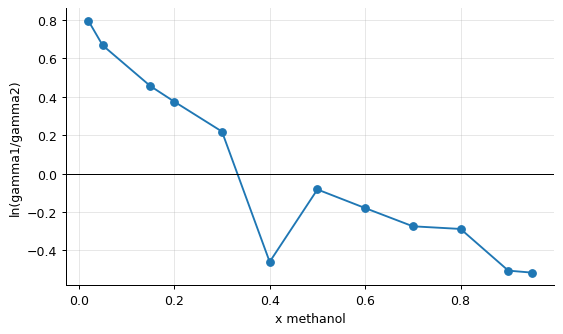

area index 0.124 (pass if < 0.10)
activity coefficients: run-01: 2.20/0.99, run-02: 1.98/1.01, run-04: 1.64/1.04, run-05: 1.52/1.05, run-06: 1.37/1.10, run-07: 1.04/1.65, run-08: 1.12/1.22, run-09: 1.06/1.27, run-10: 1.03/1.36, run-11: 1.01/1.35, run-12: 1.01/1.67, run-13: 1.00/1.67


In [4]:
T = d["T"].to_numpy() + 273.15
p = d.p_kPa.to_numpy() * 1e3
x, y = d.x_methanol.to_numpy(), d.y_methanol.to_numpy()
g1 = y * p / (x * vapor.antoine_psat("methanol", T)); g2 = (1 - y) * p / ((1 - x) * vapor.antoine_psat("water", T))
ratio = np.log(g1 / g2)
plt.plot(x, ratio, "o-"); plt.axhline(0, color="k", lw=0.8); plt.xlabel("x methanol"); plt.ylabel("ln(gamma1/gamma2)"); plt.show()
def area_index(sel):
    pos, neg = np.trapezoid(np.maximum(ratio[sel], 0), x[sel]), -np.trapezoid(np.minimum(ratio[sel], 0), x[sel])
    return abs(pos - neg) / (pos + neg)
print(f"area index {area_index(np.ones(x.size, bool)):.3f} (pass if < 0.10)")
print("activity coefficients:", ", ".join(f"{r}: {a:.2f}/{b:.2f}" for r, a, b in zip(d.run, g1, g2)))

The data set fails the area test - and the curve shows why: one point breaks an otherwise smooth trend, with
activity coefficients that jump out of line. The area test says *something* is wrong; it cannot say what.
The point must be found point by point.

## 4. Find the outlier objectively
Fit the model to all points, look at the residuals, and refit without the largest one:

In [5]:
comps = ["methanol", "water"]
def residuals(sel):
    fit = activity.fit("wilson", comps, x[sel], T[sel], p[sel], y1=y[sel])
    res = [vle.bubble_T(comps, [xi, 1 - xi], pi, fit["gamma"]) for xi, pi in zip(x, p)]
    return fit, np.array([r["T"] for r in res]) - T, np.array([r["y"][0] for r in res]) - y
fit_all, dT_all, dy_all = residuals(np.ones(x.size, bool))
worst = int(np.argmax(np.abs(dy_all)))
print(f"largest residual in y: run {d.run[worst]} ({dy_all[worst]:+.3f}; the others are within {np.max(np.delete(np.abs(dy_all), worst)):.3f})")
keep = np.ones(x.size, bool); keep[worst] = False
fit_clean, dT, dy = residuals(keep)
print(f"rms residuals: all points dT {np.sqrt(np.mean(dT_all**2)):.2f} K, dy {np.sqrt(np.mean(dy_all**2)):.3f}; "
      f"without {d.run[worst]}: dT {np.sqrt(np.mean(dT[keep]**2)):.2f} K, dy {np.sqrt(np.mean(dy[keep]**2)):.3f}")

largest residual in y: run run-07 (+0.108; the others are within 0.008)
rms residuals: all points dT 0.32 K, dy 0.031; without run-07: dT 0.24 K, dy 0.003


The residual of one run is ten times the others', and removing it cuts the remaining scatter tenfold. With
that point excluded the area test is passed comfortably:

In [6]:
print(f"area index without {d.run[worst]}: {area_index(keep):.3f} (pass if < 0.10)")

area index without run-07: 0.046 (pass if < 0.10)


A note in the laboratory log turns out to explain the point (a mis-taken vapour sample). Removing a point
needs such a reason *and* the documentation of it - never a silent deletion.

## 5. Parameters with uncertainties
How well are the two Wilson parameters determined? A bootstrap: refit to resampled data sets and look at
the spread:

In [7]:
rng = np.random.default_rng(1)
idx = np.nonzero(keep)[0]
samples = []
for _ in range(60):
    pick = rng.choice(idx, size=idx.size, replace=True)
    f = activity.fit("wilson", comps, x[pick], T[pick], p[pick], y1=y[pick], p0=[fit_clean["params"]["Lambda"][0, 1], fit_clean["params"]["Lambda"][1, 0]])
    samples.append([f["params"]["Lambda"][0, 1], f["params"]["Lambda"][1, 0]])
samples = np.array(samples)
L12, L21 = fit_clean["params"]["Lambda"][0, 1], fit_clean["params"]["Lambda"][1, 0]
print(f"Wilson Lambda12 = {L12:.3f} +/- {samples[:, 0].std():.3f}, Lambda21 = {L21:.3f} +/- {samples[:, 1].std():.3f} (bootstrap, 60 resamples)")
ginf = activity.infinite_dilution(fit_clean["gamma"], 340.0)
print(f"limiting activity coefficients at 340 K: methanol in water {ginf[0]:.2f}, water in methanol {ginf[1]:.2f}")

Wilson Lambda12 = 0.394 +/- 0.029, Lambda21 = 1.094 +/- 0.060 (bootstrap, 60 resamples)
limiting activity coefficients at 340 K: methanol in water 2.31, water in methanol 1.68


## 6. Compare with a prediction, and report

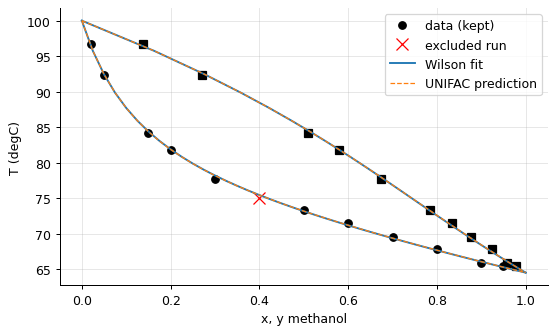

# VLE of methanol (1) + water (2) at 101.3 kPa - laboratory data reduction

Data: 12 runs; decimal comma repaired in run-11; 2 pressures converted from mmHg to kPa; 1 temperature converted from K to degC; 1 duplicated run removed; 1 run without vapour analysis dropped; run run-07 excluded (vapour sample mis-taken; residual in y +0.108).
Consistency: Redlich-Kister area index 0.046 after the exclusion (pass; 0.124 with it).
Model: Wilson, Lambda12 = 0.394 +/- 0.029, Lambda21 = 1.094 +/- 0.060;
rms deviations 0.24 K in T and 0.003 in y. No azeotrope.
Comparison: UNIFAC predicts the data within 0.5 K.



In [8]:
g_uni = unifac.gamma_function(comps)
txy_fit, txy_uni = vle.Txy(comps, 101325.0, fit_clean["gamma"], n=41), vle.Txy(comps, 101325.0, g_uni, n=41)
plt.plot(x[keep], T[keep] - 273.15, "ko", label="data (kept)"); plt.plot(y[keep], T[keep] - 273.15, "ks")
plt.plot(x[~keep], T[~keep] - 273.15, "rx", ms=9, label="excluded run")
plt.plot(txy_fit["x1"], txy_fit["T"] - 273.15, "C0", label="Wilson fit"); plt.plot(txy_fit["y1"], txy_fit["T"] - 273.15, "C0")
plt.plot(txy_uni["x1"], txy_uni["T"] - 273.15, "C1--", lw=1, label="UNIFAC prediction"); plt.plot(txy_uni["y1"], txy_uni["T"] - 273.15, "C1--", lw=1)
plt.xlabel("x, y methanol"); plt.ylabel("T (degC)"); plt.legend(); plt.show()
report = f'''# VLE of methanol (1) + water (2) at 101.3 kPa - laboratory data reduction

Data: {x.size} runs; {"; ".join(log)}; run {d.run[worst]} excluded (vapour sample mis-taken; residual in y {dy_all[worst]:+.3f}).
Consistency: Redlich-Kister area index {area_index(keep):.3f} after the exclusion (pass; {area_index(np.ones(x.size, bool)):.3f} with it).
Model: Wilson, Lambda12 = {L12:.3f} +/- {samples[:, 0].std():.3f}, Lambda21 = {L21:.3f} +/- {samples[:, 1].std():.3f};
rms deviations {np.sqrt(np.mean(dT[keep]**2)):.2f} K in T and {np.sqrt(np.mean(dy[keep]**2)):.3f} in y. No azeotrope.
Comparison: UNIFAC predicts the data within {np.max(np.abs(np.array([vle.bubble_T(comps, [xi, 1 - xi], 101325.0, g_uni)["T"] for xi in x[keep]]) - T[keep])):.1f} K.
'''
print(report)

A report that states what was measured, what was excluded and why, how consistent the data are, and how
uncertain the parameters are - so that a process designer can use the numbers with confidence, and a
reviewer can check every step from the raw file. (The file was generated for the course from UNIFAC with added
noise and faults; that is why the prediction agrees so well, and the outlier is exactly the one the file's
header confesses to.)

## Inside the algorithm: activity coefficients from one data point
Modified Raoult's law solved for the activity coefficients, $\gamma_i = y_i p/(x_i p_i^{sat})$, with the Antoine vapour pressures at
the measured temperature:

In [9]:
i = 5
Ti = T[i]
print(f"run {d.run[i]}: x = {x[i]:.3f}, y = {y[i]:.3f}, T = {Ti-273.15:.1f} degC: "
      f"gamma_methanol = {y[i]*p[i]/(x[i]*vapor.antoine_psat('methanol', Ti)):.3f}, gamma_water = {(1-y[i])*p[i]/((1-x[i])*vapor.antoine_psat('water', Ti)):.3f}")

run run-07: x = 0.400, y = 0.622, T = 75.0 degC: gamma_methanol = 1.044, gamma_water = 1.653


## Exercises
1. Repeat the fit with the NRTL model. Do both models give the same limiting activity coefficients within the bootstrap uncertainty? Which parameter is least well determined, and which data would improve it?
2. Suppose the barometer had been misread and the true pressure was 99.5 kPa throughout. Redo the analysis: how much do the fitted parameters change, and does the area test still pass? What does this say about recording the pressure?
3. **Implement it yourself:** turn steps 1-2 into a function `load_lab_vle(path)` returning a clean DataFrame in SI units and a list of the repairs made; test it on the file.